# Blood Cell Classification Test for 3 Models

**Pipeline:**
1. Rescale images to 128 (stored in fast `/content/`, not Drive)
2. Split: 100 train / 50 val / 50 test per class (8 classes, 400 test images)
3. Train 3 models (EfficientNetB0, MobileNetV2, DenseNet121) 10 runs each with different random seeds (42\u201351), 30 total training runs. Checkpoints: `{Model}_run{0-9}_best.keras` saved to Drive
4. Training curves: mean 1 std across 10 runs per model, individual runs as faint lines
5. Final evaluation: all 30 checkpoints evaluated on test set aggregated stats (mean, std, min, max, 95% CI), pairwise t-tests, confusion matrices (median run), per-class recall with error bars, accuracy boxplots. Results saved to `evaluation_results.json`

**Optimizations:** mixed precision, 128\u00d7128 input, 10 epochs, head-only transfer, `/content/` working dir, on-the-fly augmentation, early stopping (patience=5)


## 0. Setup & Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, json, shutil, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dropout, Dense,
                                      RandomFlip, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, DenseNet121

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print('TF:', tf.__version__)

TF: 2.20.0


In [4]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision:', tf.keras.mixed_precision.global_policy().compute_dtype)
print('GPU:', tf.config.list_physical_devices('GPU'))

Mixed precision: float16
GPU: []


In [5]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
CLASS_NAMES = sorted(['basophil', 'eosinophil', 'erythroblast', 'ig',
                       'lymphocyte', 'monocyte', 'neutrophil', 'platelet'])
NUM_CLASSES = len(CLASS_NAMES)

DRIVE_SRC  = Path('/content/drive/MyDrive/bloodcellsAI/bloodcells_dataset')
DRIVE_OUT  = Path('/content/drive/MyDrive/bloodcellsAI/models')

WORK     = Path('/content/bloodcells')
RESCALED = WORK / 'rescaled'
TRAIN_DIR = WORK / 'train'
VAL_DIR   = WORK / 'val'
TEST_DIR  = WORK / 'test'

N_RUNS = 10
MODEL_NAMES = ['EfficientNetB0', 'MobileNetV2', 'DenseNet121']

os.makedirs(DRIVE_OUT, exist_ok=True)
print(f'Classes: {CLASS_NAMES}')
print(f'Image size: {IMG_SIZE}, Epochs: {EPOCHS}, Batch: {BATCH_SIZE}')

Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Image size: (128, 128), Epochs: 10, Batch: 32


## 1. Image Rescaling (300 → 128×128)

In [10]:
def rescale_images(src_dir, dst_dir, img_size):
    for class_name in CLASS_NAMES:
        src_cls = src_dir / class_name
        dst_cls = dst_dir / class_name
        dst_cls.mkdir(parents=True, exist_ok=True)
        for img_path in tqdm(sorted(src_cls.glob('*.jpg')), desc=f'Rescale {class_name}'):
            with Image.open(img_path) as img:
                img.convert('RGB').resize(img_size, Image.LANCZOS).save(
                    dst_cls / img_path.name, 'JPEG', quality=90)

os.makedirs(RESCALED, exist_ok=True)
rescale_images(DRIVE_SRC, RESCALED, IMG_SIZE)
print('Rescaling done.')

Rescale basophil:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale eosinophil:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale erythroblast:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale ig:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale lymphocyte:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale monocyte:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale neutrophil:   0%|          | 0/200 [00:00<?, ?it/s]

Rescale platelet:   0%|          | 0/200 [00:00<?, ?it/s]

Rescaling done.


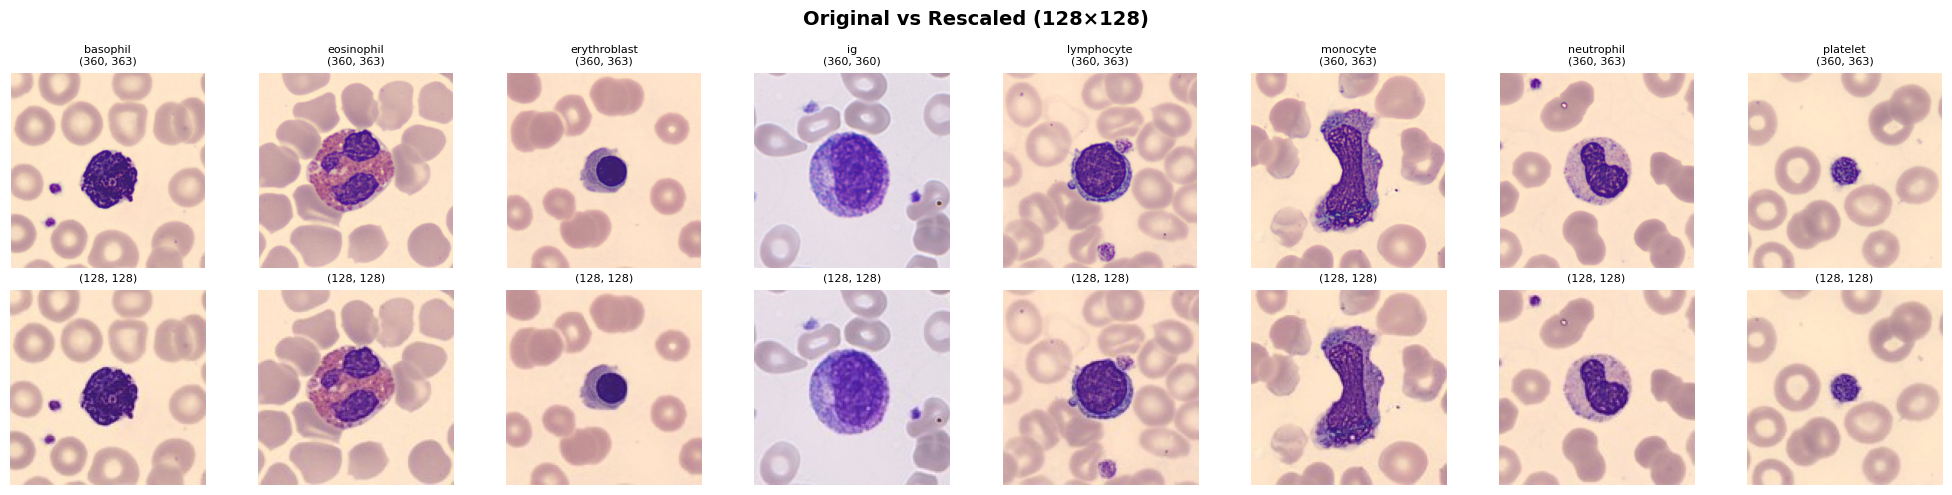

In [11]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 5))
fig.suptitle('Original vs Rescaled (128×128)', fontsize=14, fontweight='bold')
for i, cn in enumerate(CLASS_NAMES):
    orig = Image.open(sorted((DRIVE_SRC / cn).glob('*.jpg'))[0]).convert('RGB')
    new  = Image.open(sorted((RESCALED / cn).glob('*.jpg'))[0]).convert('RGB')
    axes[0,i].imshow(orig); axes[0,i].set_title(f'{cn}\n{orig.size}', fontsize=8); axes[0,i].axis('off')
    axes[1,i].imshow(new);  axes[1,i].set_title(f'{new.size}', fontsize=8); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('128×128', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

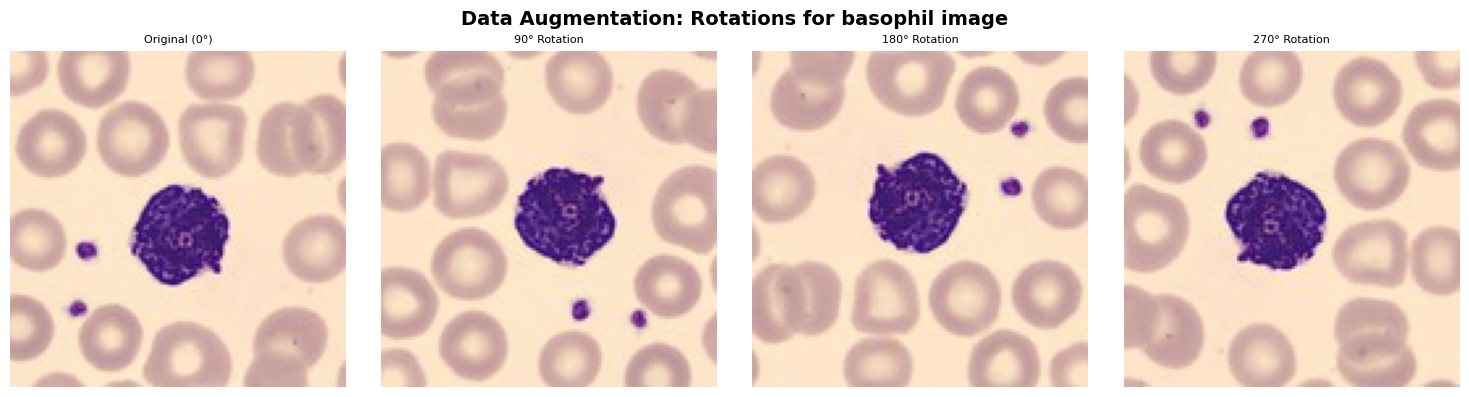

In [12]:
example_class = CLASS_NAMES[0]
example_image_path = sorted((RESCALED / example_class).glob('*.jpg'))[0]

original_image = Image.open(example_image_path).convert('RGB')

rotation_angles = [0, 90, 180, 270]

fig, axes = plt.subplots(1, len(rotation_angles), figsize=(15, 4))
fig.suptitle(f'Data Augmentation: Rotations for {example_class} image', fontsize=14, fontweight='bold')

for i, angle in enumerate(rotation_angles):
    if angle == 0:
        rotated_image = original_image
        title = 'Original (0°)'
    else:
        rotated_image = original_image.rotate(angle, expand=False)
        title = f'{angle}° Rotation'

    axes[i].imshow(rotated_image)
    axes[i].set_title(title, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2. Dataset Splitting

Per class: 100 train / 50 validation / 50 test (final evaluation).

In [13]:
def count_imgs(d): return {cn: len(list((d/cn).glob('*.jpg'))) for cn in CLASS_NAMES}

def split_dataset(src_dir, train_dir, val_dir, test_dir):
    for cn in CLASS_NAMES:
        for d in [train_dir, val_dir, test_dir]:
            (d / cn).mkdir(parents=True, exist_ok=True)
        files = sorted((src_dir / cn).glob('*.jpg'))
        random.shuffle(files)
        for f in files[:100]:   shutil.copy2(f, train_dir / cn / f.name)
        for f in files[100:150]: shutil.copy2(f, val_dir / cn / f.name)
        for f in files[150:200]: shutil.copy2(f, test_dir / cn / f.name)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]: os.makedirs(d, exist_ok=True)
split_dataset(RESCALED, TRAIN_DIR, VAL_DIR, TEST_DIR)

tc, vc, xc = count_imgs(TRAIN_DIR), count_imgs(VAL_DIR), count_imgs(TEST_DIR)
for cn in CLASS_NAMES:
    print(f'{cn:15s}  train:{tc[cn]}  val:{vc[cn]}  test:{xc[cn]}')
print(f'Total: train={sum(tc.values())}  val={sum(vc.values())}  test={sum(xc.values())}')

basophil         train:100  val:50  test:50
eosinophil       train:100  val:50  test:50
erythroblast     train:100  val:50  test:50
ig               train:100  val:50  test:50
lymphocyte       train:100  val:50  test:50
monocyte         train:100  val:50  test:50
neutrophil       train:100  val:50  test:50
platelet         train:100  val:50  test:50
Total: train=800  val=400  test=400


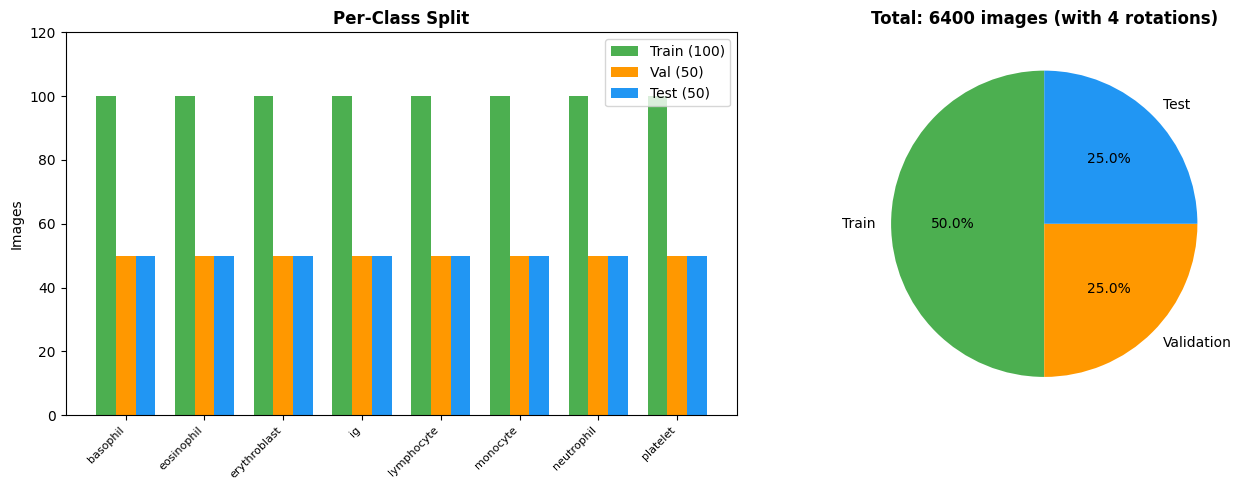

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(NUM_CLASSES); w = 0.25
ax1.bar(x-w, tc.values(), w, label='Train (100)', color='#4CAF50')
ax1.bar(x,   vc.values(), w, label='Val (50)',   color='#FF9800')
ax1.bar(x+w, xc.values(), w, label='Test (50)',   color='#2196F3')
ax1.set_xticks(x); ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Images'); ax1.set_title('Per-Class Split', fontweight='bold')
ax1.legend(); ax1.set_ylim(0, 120)

original_total = sum(tc.values())+sum(vc.values())+sum(xc.values())
rotation_factor = 4
total_with_rotations = original_total * rotation_factor

ax2.pie([sum(tc.values()), sum(vc.values()), sum(xc.values())],
        labels=['Train','Validation','Test'], autopct='%1.1f%%',
        colors=['#4CAF50','#FF9800','#2196F3'], startangle=90)
ax2.set_title(f'Total: {total_with_rotations} images (with 4 rotations)', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Model Training

**Each model has its own cell below.** You can run them in different Colab sessions.
Models and training history are saved to Google Drive.

**How it works across sessions:**
- First session: run all setup cells → pick one model cell → train → checkpoint saved to Drive
- Next session: run all setup cells → pick next model cell → train → checkpoint saved to Drive
- If a checkpoint already exists, the cell skips training (prints "ALREADY TRAINED").
  Set `FORCE_RETRAIN = True` to override.

In [6]:
PREPROCESS = {
    'EfficientNetB0': tf.keras.applications.efficientnet.preprocess_input,
    'MobileNetV2':    tf.keras.applications.mobilenet_v2.preprocess_input,
    'DenseNet121':    tf.keras.applications.densenet.preprocess_input,
}
BASES = {
    'EfficientNetB0': EfficientNetB0,
    'MobileNetV2':    MobileNetV2,
    'DenseNet121':    DenseNet121,
}

In [7]:
def build_model(model_name, img_size, num_classes):
    preprocess = PREPROCESS[model_name]
    base = BASES[model_name](weights='imagenet', include_top=False,
                              input_shape=(*img_size, 3))
    base.trainable = False

    inputs = Input(shape=(*img_size, 3))
    x = Lambda(preprocess, name='preprocess')(inputs)
    x = RandomFlip('horizontal_and_vertical', name='augmentation')(x)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inputs, outputs)

In [8]:
def create_datasets(train_dir, val_dir, test_dir, img_size, batch_size):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        str(train_dir), image_size=img_size, batch_size=batch_size,
        label_mode='categorical', seed=RANDOM_SEED, shuffle=True, class_names=CLASS_NAMES)
    train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        str(val_dir), image_size=img_size, batch_size=batch_size,
        label_mode='categorical', seed=RANDOM_SEED, shuffle=False, class_names=CLASS_NAMES)
    val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

    test_ds = tf.keras.utils.image_dataset_from_directory(
        str(test_dir), image_size=img_size, batch_size=batch_size,
        label_mode='categorical', seed=RANDOM_SEED, shuffle=False, class_names=CLASS_NAMES)
    test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [15]:
# Prepare shared datasets (run once before training any model)
train_ds, val_ds, test_ds = create_datasets(TRAIN_DIR, VAL_DIR, TEST_DIR, IMG_SIZE, BATCH_SIZE)
print('Datasets ready.')

Found 800 files belonging to 8 classes.
Found 400 files belonging to 8 classes.
Found 400 files belonging to 8 classes.
Datasets ready.


### Multi-Run Training (10 runs × 3 models)

Each model is trained 10 times with different random seeds (42–51).
Best checkpoint per run saved as `{Model}_run{0-9}_best.keras` in Drive.
Run each cell independently — restart runtime between models for clean GPU memory.


In [27]:
MODEL_NAME = 'EfficientNetB0'
FORCE_RETRAIN = False

for run_id in range(N_RUNS):
    seed = RANDOM_SEED + run_id
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    ckpt_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_best.keras'
    hist_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_history.json'

    if ckpt_path.exists() and not FORCE_RETRAIN:
        print(f'[SKIP] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — already trained')
        continue

    print(f'\n{"="*60}')
    print(f'[TRAINING] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — {EPOCHS} epochs')
    print(f'{"="*60}')

    model = build_model(MODEL_NAME, IMG_SIZE, NUM_CLASSES)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        ModelCheckpoint(str(ckpt_path), monitor='val_accuracy', save_best_only=True,
                        mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                        callbacks=callbacks, verbose=1)

    hist_dict = {k: [float(v) for v in history.history[k]] for k in history.history}
    with open(hist_path, 'w') as f:
        json.dump(hist_dict, f)
    print(f'[DONE] Run {run_id} saved -> {ckpt_path.name}')



[TRAINING] EfficientNetB0 run 0/9 (seed=42) — 10 epochs
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 644ms/step - accuracy: 0.3925 - loss: 1.6462 - val_accuracy: 0.5750 - val_loss: 1.1362
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 567ms/step - accuracy: 0.6150 - loss: 1.0698 - val_accuracy: 0.7400 - val_loss: 0.8504
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 584ms/step - accuracy: 0.6725 - loss: 0.9216 - val_accuracy: 0.7275 - val_loss: 0.7804
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 572ms/step - accuracy: 0.7138 - loss: 0.8423 - val_accuracy: 0.7900 - val_loss: 0.6761
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 574ms/step - accuracy: 0.7525 - loss: 0.7474 - val_accuracy: 0.7950 - val_loss: 0.6556
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 539ms/step - accuracy: 0.7663 - loss: 0.6751 - val_accuracy: 0.8075 - val_loss: 0.6310
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 576ms/step - accuracy: 0.7600 - loss: 0.6704 - val_accuracy: 0.7950 - val_lo

In [28]:
MODEL_NAME = 'MobileNetV2'
FORCE_RETRAIN = False

for run_id in range(N_RUNS):
    seed = RANDOM_SEED + run_id
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    ckpt_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_best.keras'
    hist_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_history.json'

    if ckpt_path.exists() and not FORCE_RETRAIN:
        print(f'[SKIP] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — already trained')
        continue

    print(f'\n{"="*60}')
    print(f'[TRAINING] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — {EPOCHS} epochs')
    print(f'{"="*60}')

    model = build_model(MODEL_NAME, IMG_SIZE, NUM_CLASSES)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        ModelCheckpoint(str(ckpt_path), monitor='val_accuracy', save_best_only=True,
                        mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                        callbacks=callbacks, verbose=1)

    hist_dict = {k: [float(v) for v in history.history[k]] for k in history.history}
    with open(hist_path, 'w') as f:
        json.dump(hist_dict, f)
    print(f'[DONE] Run {run_id} saved -> {ckpt_path.name}')



[TRAINING] MobileNetV2 run 0/9 (seed=42) — 10 epochs
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 402ms/step - accuracy: 0.4437 - loss: 1.6133 - val_accuracy: 0.7275 - val_loss: 0.8519
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 361ms/step - accuracy: 0.7275 - loss: 0.8113 - val_accuracy: 0.8000 - val_loss: 0.5938
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 359ms/step - accuracy: 0.7862 - loss: 0.6186 - val_accuracy: 0.8275 - val_loss: 0.5116
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 331ms/step - accuracy: 0.8037 - loss: 0.5697 - val_accuracy: 0.8525 - val_loss: 0.4612
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - accuracy: 0.8450 - loss: 0.4529 - val_accuracy: 0.8425 - val_loss: 0.4769
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - accuracy: 0.8500 - loss: 0.4266 - val_accuracy: 0.8675 - val_loss: 0.4477
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 353ms/step - accuracy: 0.8587 - loss: 0.4389 - val_accuracy: 0.8200 - val_loss: 0.5127

In [29]:
MODEL_NAME = 'DenseNet121'
FORCE_RETRAIN = False

for run_id in range(N_RUNS):
    seed = RANDOM_SEED + run_id
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    ckpt_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_best.keras'
    hist_path = DRIVE_OUT / f'{MODEL_NAME}_run{run_id}_history.json'

    if ckpt_path.exists() and not FORCE_RETRAIN:
        print(f'[SKIP] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — already trained')
        continue

    print(f'\n{"="*60}')
    print(f'[TRAINING] {MODEL_NAME} run {run_id}/{N_RUNS-1} (seed={seed}) — {EPOCHS} epochs')
    print(f'{"="*60}')

    model = build_model(MODEL_NAME, IMG_SIZE, NUM_CLASSES)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        ModelCheckpoint(str(ckpt_path), monitor='val_accuracy', save_best_only=True,
                        mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                        callbacks=callbacks, verbose=1)

    hist_dict = {k: [float(v) for v in history.history[k]] for k in history.history}
    with open(hist_path, 'w') as f:
        json.dump(hist_dict, f)
    print(f'[DONE] Run {run_id} saved -> {ckpt_path.name}')



[TRAINING] DenseNet121 run 0/9 (seed=42) — 10 epochs
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.3063 - loss: 2.1933 - val_accuracy: 0.5125 - val_loss: 1.2871
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5450 - loss: 1.3304 - val_accuracy: 0.7300 - val_loss: 0.9209
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6562 - loss: 1.0515 - val_accuracy: 0.7850 - val_loss: 0.7781
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6775 - loss: 0.9263 - val_accuracy: 0.7875 - val_loss: 0.7001
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6800 - loss: 0.9092 - val_accuracy: 0.7900 - val_loss: 0.6752
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7325 - loss: 0.7652 - val_accuracy: 0.8150 - val_loss: 0.6296
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7262 - loss: 0.7847 - val_accuracy: 0.7750 - val_loss: 0.7135
Epoch 8/10
25

### Training Curves (10 runs per model)

Mean ± 1 std across 10 runs, with individual runs shown as faint lines.
Run after all models are fully trained (all 30 runs complete).


Loaded EfficientNetB0: 10 runs
Loaded MobileNetV2: 10 runs
Loaded DenseNet121: 10 runs


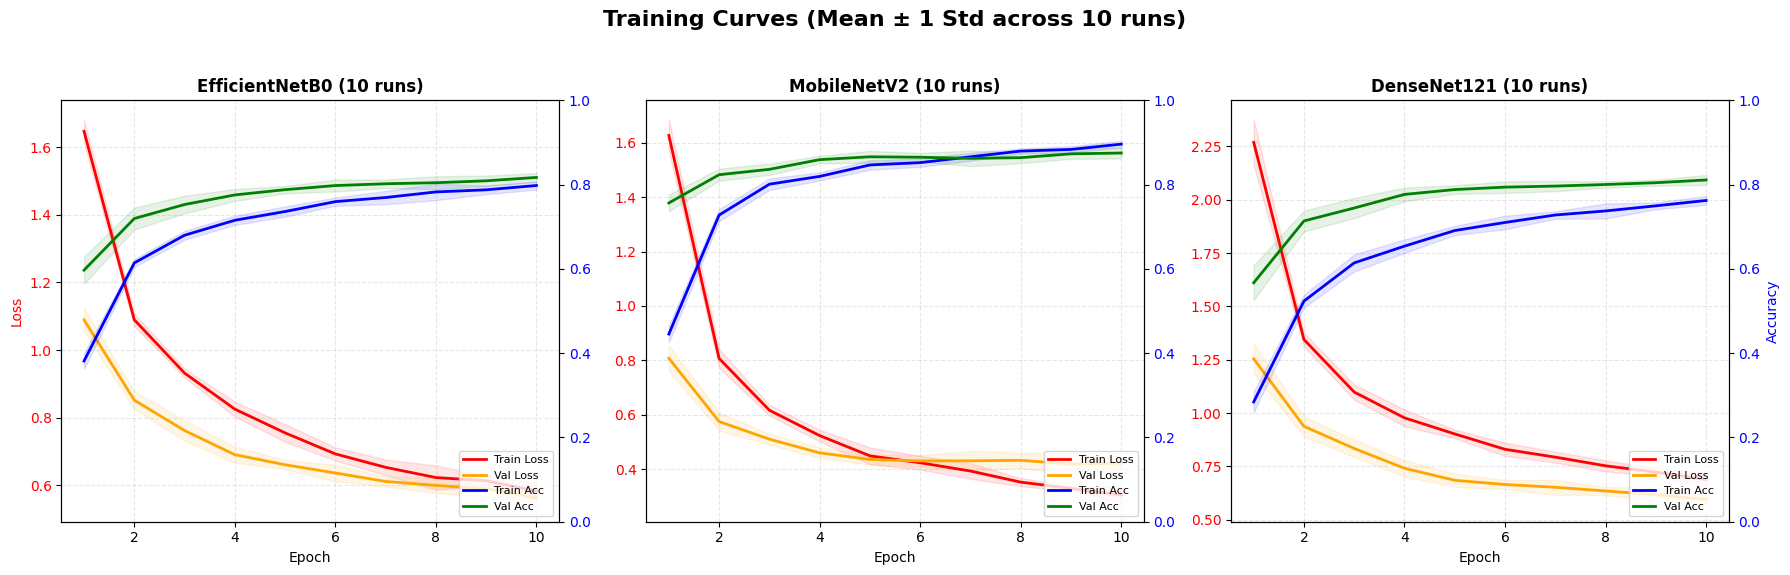

In [19]:
histories = {}
for mn in MODEL_NAMES:
    histories[mn] = []
    for run_id in range(N_RUNS):
        hp = DRIVE_OUT / f'{mn}_run{run_id}_history.json'
        if hp.exists():
            with open(hp) as f:
                histories[mn].append(json.load(f))
    if histories[mn]:
        print(f'Loaded {mn}: {len(histories[mn])} runs')
    else:
        print(f'[MISSING] {mn} — train it first')

# Filter models that actually have histories
MODEL_NAMES_WITH_HISTORY = [mn for mn in MODEL_NAMES if histories[mn]]

if not MODEL_NAMES_WITH_HISTORY: # No models have histories
    print('No histories found for any model. Train at least one model first.')
else:
    overall_max_epochs = 0
    for mn in MODEL_NAMES_WITH_HISTORY:
        overall_max_epochs = max(overall_max_epochs, max(len(h['loss']) for h in histories[mn]))

    def pad_history(h, target_len):
        padded = {}
        for k in ['loss', 'val_loss', 'accuracy', 'val_accuracy']:
            vals = h[k]
            if len(vals) < target_len:
                vals = list(vals) + [vals[-1]] * (target_len - len(vals))
            padded[k] = vals
        return padded

    # Create a single figure with N columns (one for each model)
    fig, axes = plt.subplots(1, len(MODEL_NAMES_WITH_HISTORY), figsize=(6 * len(MODEL_NAMES_WITH_HISTORY), 6), sharex=True)
    if len(MODEL_NAMES_WITH_HISTORY) == 1: # Handle case of single model for indexing
        axes = [axes] # Make it iterable

    fig.suptitle('Training Curves (Mean ± 1 Std across 10 runs)', fontsize=16, fontweight='bold')

    for col_idx, mn in enumerate(MODEL_NAMES_WITH_HISTORY):
        ax1 = axes[col_idx]
        ax2 = ax1.twinx() # Create a second y-axis for accuracy

        padded = [pad_history(h, overall_max_epochs) for h in histories[mn]]
        epochs = range(1, overall_max_epochs + 1)

        # Calculate means and stds
        all_loss = np.array([h['loss'] for h in padded])
        all_val_loss = np.array([h['val_loss'] for h in padded])
        all_acc = np.array([h['accuracy'] for h in padded])
        all_val_acc = np.array([h['val_accuracy'] for h in padded])

        # Plot Loss on ax1 (left y-axis)
        p1 = ax1.plot(epochs, all_loss.mean(axis=0), 'r-', linewidth=2, label='Train Loss')
        ax1.fill_between(epochs, all_loss.mean(axis=0) - all_loss.std(axis=0),
                         all_loss.mean(axis=0) + all_loss.std(axis=0), color='r', alpha=0.1)
        p2 = ax1.plot(epochs, all_val_loss.mean(axis=0), 'orange', linewidth=2, label='Val Loss')
        ax1.fill_between(epochs, all_val_loss.mean(axis=0) - all_val_loss.std(axis=0),
                         all_val_loss.mean(axis=0) + all_val_loss.std(axis=0), color='orange', alpha=0.1)
        ax1.set_xlabel('Epoch')
        if col_idx == 0: # Only set ylabel for the first subplot
            ax1.set_ylabel('Loss', color='red')
        ax1.tick_params(axis='y', labelcolor='red')
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_title(f'{mn} ({len(histories[mn])} runs)', fontsize=12, fontweight='bold')

        # Plot Accuracy on ax2 (right y-axis)
        p3 = ax2.plot(epochs, all_acc.mean(axis=0), 'b-', linewidth=2, label='Train Acc')
        ax2.fill_between(epochs, all_acc.mean(axis=0) - all_acc.std(axis=0),
                         all_acc.mean(axis=0) + all_acc.std(axis=0), color='b', alpha=0.1)
        p4 = ax2.plot(epochs, all_val_acc.mean(axis=0), 'g-', linewidth=2, label='Val Acc')
        ax2.fill_between(epochs, all_val_acc.mean(axis=0) - all_val_acc.std(axis=0),
                         all_val_acc.mean(axis=0) + all_val_acc.std(axis=0), color='g', alpha=0.1)
        if col_idx == len(MODEL_NAMES_WITH_HISTORY) - 1: # Only set ylabel for the last subplot
            ax2.set_ylabel('Accuracy', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        ax2.set_ylim(0, 1)

        # Combine legends from both axes
        lines = p1 + p2 + p3 + p4
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='lower right', fontsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

## 4. Final Evaluation (10 runs per model)

Load all 10 checkpoints per model, evaluate on held-out test set (50 images/class, 400 total).
Report aggregated statistics: mean, std, min, max, 95% CI, pairwise t-tests.


In [18]:
def evaluate_checkpoint(model_name, run_id, test_ds):
    ckpt_path = str(DRIVE_OUT / f'{model_name}_run{run_id}_best.keras')
    model = build_model(model_name, IMG_SIZE, NUM_CLASSES)
    model.load_weights(ckpt_path)
    y_true, y_pred = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm

from scipy import stats as scipy_stats

eval_results = {}
for mn in MODEL_NAMES:
    eval_results[mn] = []
    for run_id in range(N_RUNS):
        ckpt = str(DRIVE_OUT / f'{mn}_run{run_id}_best.keras')
        if not os.path.exists(ckpt):
            print(f'[MISSING] {mn} run {run_id} — skipping')
            continue
        acc, rep, cm = evaluate_checkpoint(mn, run_id, test_ds)
        eval_results[mn].append({
            'run': run_id, 'accuracy': float(acc),
            'report': rep, 'cm': cm.tolist()
        })
        print(f'  {mn} run {run_id}: acc={acc:.4f}')

print(f'\n{"="*70}')
print(f'FINAL RANKING — {N_RUNS} runs per model')
print(f'{"="*70}')
ranking = []
for mn in MODEL_NAMES:
    if eval_results[mn]:
        accs = [r['accuracy'] for r in eval_results[mn]]
        mean_acc = np.mean(accs)
        std_acc = np.std(accs, ddof=1)
        n = len(accs)
        ci = scipy_stats.t.interval(0.95, df=n-1, loc=mean_acc, scale=std_acc/np.sqrt(n)) if n > 1 else (mean_acc, mean_acc)
        ranking.append((mn, mean_acc, std_acc, ci, np.min(accs), np.max(accs)))

ranking.sort(key=lambda x: -x[1])

print(f'{"Model":<20s} {"Mean":>8s} {"Std":>8s} {"95% CI":>20s} {"Min":>8s} {"Max":>8s}')
print('-' * 75)
for mn, mean_acc, std_acc, ci, min_acc, max_acc in ranking:
    print(f'{mn:<20s} {mean_acc:8.4f} {std_acc:8.4f} [{ci[0]:.4f}, {ci[1]:.4f}]  {min_acc:8.4f} {max_acc:8.4f}')

  EfficientNetB0 run 0: acc=0.8275
  EfficientNetB0 run 1: acc=0.8425
  EfficientNetB0 run 2: acc=0.8500
  EfficientNetB0 run 3: acc=0.8625
  EfficientNetB0 run 4: acc=0.8550
  EfficientNetB0 run 5: acc=0.8425
  EfficientNetB0 run 6: acc=0.8325
  EfficientNetB0 run 7: acc=0.8250
  EfficientNetB0 run 8: acc=0.8225
  EfficientNetB0 run 9: acc=0.8300
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MobileNetV2 run 0: acc=0.9050
  MobileNetV2 run 1: acc=0.9075
  MobileNetV2 run 2: acc=0.8900
  MobileNetV2 run 3: acc=0.8775
  MobileNetV2 run 4: acc=0.8800
  MobileNetV2 run 5: acc=0.9125
  MobileNetV2 run 6: acc=0.8925
  MobileNetV2 run 7: acc=0.8975
  MobileNetV2 run 8: acc=0.8875
  MobileNetV2 run 9: acc=0.8850
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  DenseNet121 run 0: acc=0.7850
  DenseNet121 run 1: acc=0.8125
  DenseNet121 run 2: acc=0.8150
  DenseNet121 run 3: acc=0.8150
  DenseNet121 run 4: acc=0.7975
  DenseNet121 run 5: acc=0.8200
  DenseNet121 run 6: acc=0.8400
  Dens

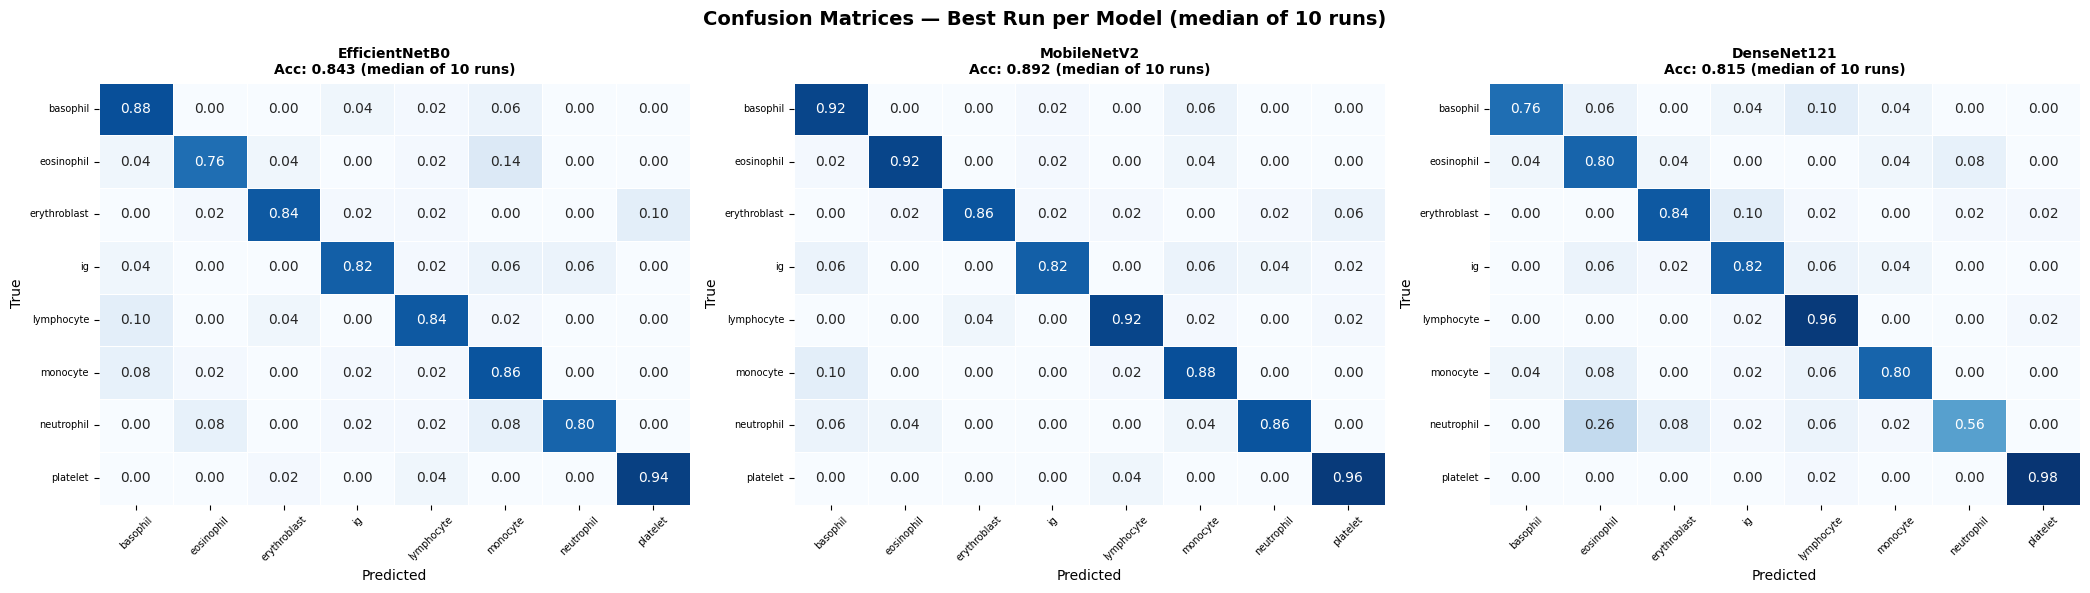

In [20]:
if eval_results:
    trained = [mn for mn in MODEL_NAMES if eval_results[mn]]
    fig, axes = plt.subplots(1, len(trained), figsize=(7*len(trained), 6))
    if len(trained) == 1:
        axes = [axes]
    fig.suptitle(f'Confusion Matrices — Best Run per Model (median of {N_RUNS} runs)', fontsize=14, fontweight='bold')

    for ax, mn in zip(axes, trained):
        runs = eval_results[mn]
        accs = [r['accuracy'] for r in runs]
        median_idx = np.argsort(accs)[len(accs)//2]
        best_run = runs[median_idx]
        cm = np.array(best_run['cm'])
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    vmin=0, vmax=1, ax=ax, cbar=False, linewidths=0.5)
        ax.set_title(f'{mn}\nAcc: {best_run["accuracy"]:.3f} (median of {N_RUNS} runs)', fontweight='bold', fontsize=10)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
    plt.tight_layout(); plt.show()


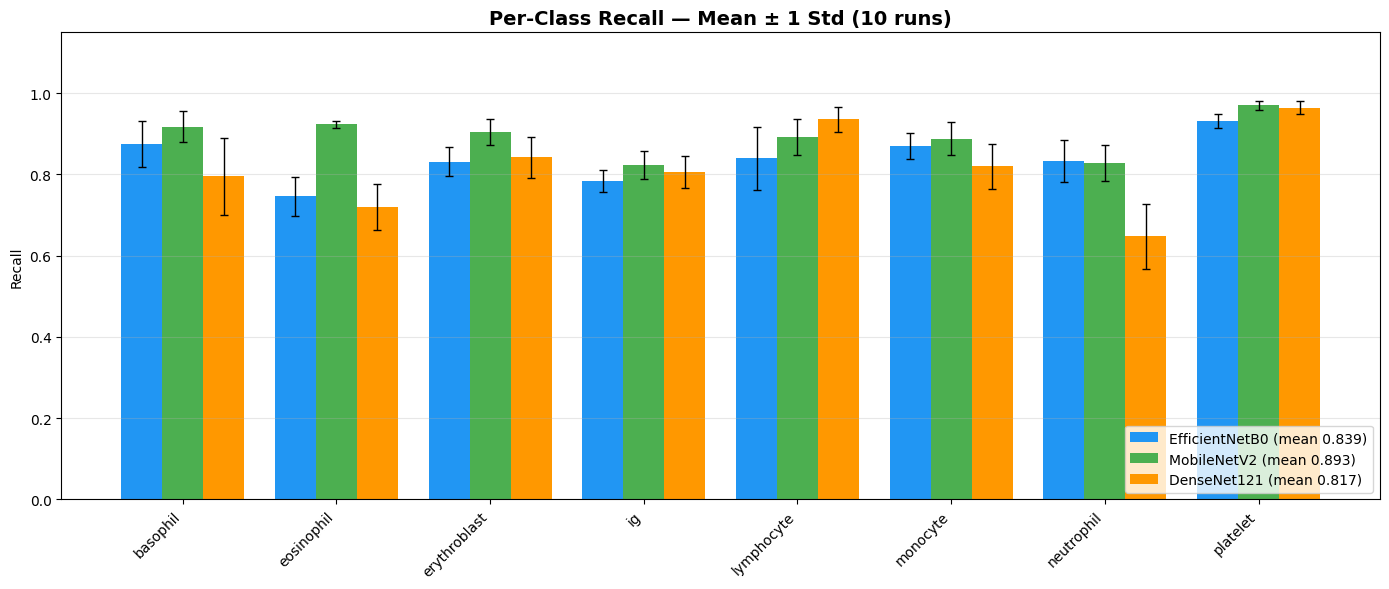

In [21]:
if eval_results:
    trained = [mn for mn in MODEL_NAMES if eval_results[mn]]
    fig, ax = plt.subplots(figsize=(14, 6))

    per_class_data = {}
    for mn in trained:
        per_class_data[mn] = {cn: [] for cn in CLASS_NAMES}
        for run in eval_results[mn]:
            for cn in CLASS_NAMES:
                per_class_data[mn][cn].append(run['report'][cn]['recall'])

    x = np.arange(NUM_CLASSES); w = 0.8 / len(trained)
    colors = ['#2196F3', '#4CAF50', '#FF9800'][:len(trained)]

    for i, (mn, c) in enumerate(zip(trained, colors)):
        means = [np.mean(per_class_data[mn][cn]) for cn in CLASS_NAMES]
        stds = [np.std(per_class_data[mn][cn], ddof=1) for cn in CLASS_NAMES]
        offset = (i - len(trained)/2 + 0.5) * w
        mean_acc = np.mean([r['accuracy'] for r in eval_results[mn]])
        ax.bar(x + offset, means, w, label=f'{mn} (mean {mean_acc:.3f})', color=c,
               yerr=stds, capsize=3, error_kw={'linewidth': 1})

    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_ylabel('Recall'); ax.set_title(f'Per-Class Recall — Mean ± 1 Std ({N_RUNS} runs)', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


/tmp/ipykernel_3998/1411789958.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=trained, patch_artist=True,


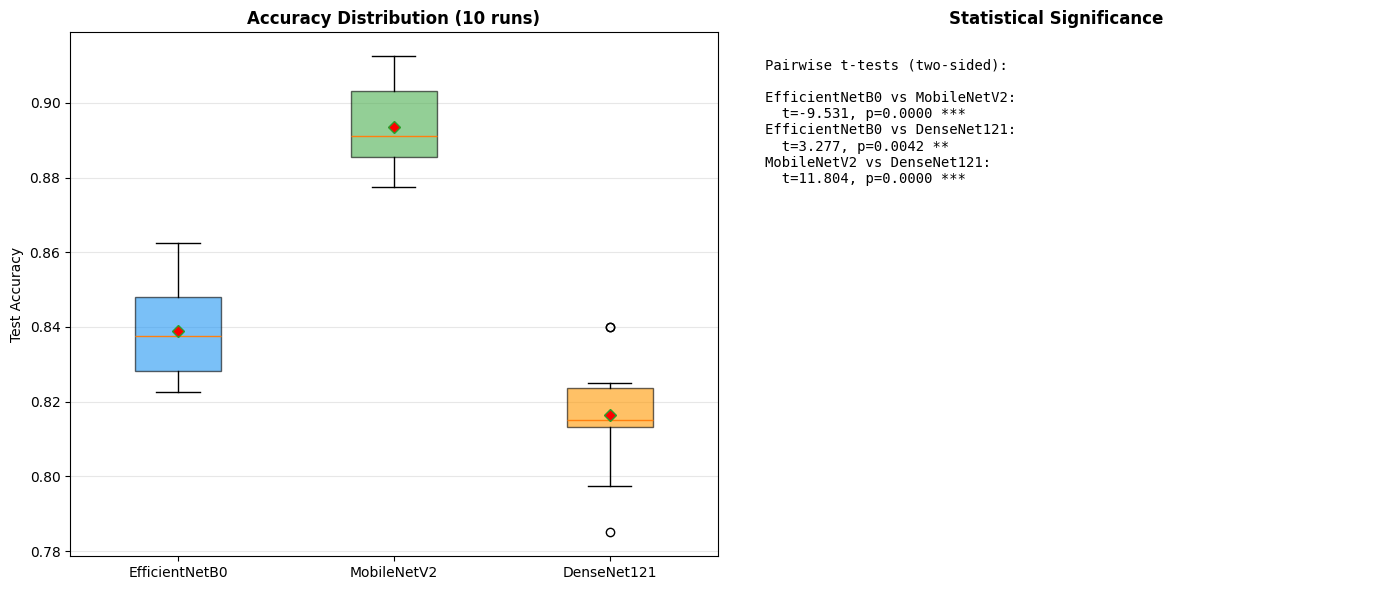

In [22]:
if eval_results:
    trained = [mn for mn in MODEL_NAMES if eval_results[mn]]
    colors = ['#2196F3', '#4CAF50', '#FF9800'][:len(trained)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    box_data = [[r['accuracy'] for r in eval_results[mn]] for mn in trained]
    bp = ax1.boxplot(box_data, labels=trained, patch_artist=True,
                     widths=0.4, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax1.set_ylabel('Test Accuracy'); ax1.set_title(f'Accuracy Distribution ({N_RUNS} runs)', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Pairwise t-tests
    ax2.axis('off')
    text_lines = ['Pairwise t-tests (two-sided):\n']
    for i in range(len(trained)):
        for j in range(i+1, len(trained)):
            a, b = box_data[i], box_data[j]
            t_stat, p_val = scipy_stats.ttest_ind(a, b)
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
            text_lines.append(f'{trained[i]} vs {trained[j]}:')
            text_lines.append(f'  t={t_stat:.3f}, p={p_val:.4f} {sig}')
    ax2.text(0.05, 0.95, '\n'.join(text_lines), transform=ax2.transAxes,
             fontsize=10, fontfamily='monospace', verticalalignment='top')
    ax2.set_title('Statistical Significance', fontweight='bold')
    plt.tight_layout(); plt.show()


In [23]:
if eval_results:
    aggregated = {}
    for mn in eval_results:
        if not eval_results[mn]:
            continue
        accs = [r['accuracy'] for r in eval_results[mn]]
        mean_acc = np.mean(accs)
        std_acc = np.std(accs, ddof=1)
        n = len(accs)
        ci = scipy_stats.t.interval(0.95, df=n-1, loc=mean_acc, scale=std_acc/np.sqrt(n)) if n > 1 else (mean_acc, mean_acc)

        per_class_agg = {}
        for cn in CLASS_NAMES:
            recalls = [r['report'][cn]['recall'] for r in eval_results[mn]]
            precisions = [r['report'][cn]['precision'] for r in eval_results[mn]]
            f1s = [r['report'][cn]['f1-score'] for r in eval_results[mn]]
            per_class_agg[cn] = {
                'recall':    {'mean': float(np.mean(recalls)),    'std': float(np.std(recalls, ddof=1))},
                'precision': {'mean': float(np.mean(precisions)), 'std': float(np.std(precisions, ddof=1))},
                'f1-score':  {'mean': float(np.mean(f1s)),        'std': float(np.std(f1s, ddof=1))},
            }

        aggregated[mn] = {
            'n_runs': n,
            'accuracy': {
                'mean': float(mean_acc), 'std': float(std_acc),
                'min': float(np.min(accs)), 'max': float(np.max(accs)),
                'ci_95': [float(ci[0]), float(ci[1])]
            },
            'per_class': per_class_agg,
            'runs': eval_results[mn]
        }

    out = DRIVE_OUT / 'evaluation_results.json'
    with open(out, 'w') as f:
        json.dump(aggregated, f, indent=2)
    print(f'Results saved to {{out}}')
    print(f'  Contains: aggregated stats + {{sum(len(v["runs"]) for v in aggregated.values())}} raw runs')


Results saved to {out}
  Contains: aggregated stats + {sum(len(v["runs"]) for v in aggregated.values())} raw runs
